In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Updated Label Mapping
label_map = {
    'benign': 0, 'adware': 1, 'backdoor': 2, 'banker': 3, 'dropper': 4,
    'fileinjector': 5, 'NoCategory': 6, 'PUA': 7, 'Ransomware': 8,
    'Riskware': 9, 'SMS': 10, 'Scareware': 11, 'Spy': 12, 'Trojan': 13, 'Zeroday': 14
}

# Load datasets (Replace 'malware_multiclass.csv' with your actual multiclass filename)
benign_df = pd.read_csv("processedData/benign.csv")
mal_df = pd.read_csv("processedData/malware_multiclass.csv") 

# Reset columns to ensure consistency before concatenation
benign_df.columns = range(benign_df.shape[1])
mal_df.columns = range(mal_df.shape[1])

# Concatenate datasets
df = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)

# Ensure feature 9504 contains the integer values 0-14 according to label_map
print("Value counts for multiclass labels:")
print(df[9504].value_counts())

Value counts for multiclass labels:
9504
0     162181
9      97349
1      47210
13     13559
14     13340
8       6202
12      3540
10      3125
4       2302
6       2296
7       2051
11      1556
2       1538
3        887
5        669
Name: count, dtype: int64


In [3]:


X = df.drop(9504, axis=1).select_dtypes(include=[np.number])  # also drop hash column (1)
y = df[9504]

# Compute correlation of each feature with label
correlations = X.corrwith(y)

# Sort by absolute correlation
corr_sorted = correlations.abs().sort_values(ascending=False)

print(corr_sorted.head(20))

/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


57      0.625832
58      0.576507
50      0.545256
3052    0.527072
63      0.527072
51      0.520906
36      0.517919
66      0.516079
25      0.497445
107     0.486376
37      0.482874
48      0.481772
3293    0.468584
39      0.467057
3395    0.444482
35      0.435223
143     0.428497
3409    0.423443
128     0.423177
3536    0.415671
dtype: float64


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns)
top_features = mi_scores.sort_values(ascending=False).head(50)

Selected feature indices: [57, 58, 50, 3052, 63, 51, 36, 66, 25, 107, 37, 48, 3293, 39, 3395, 35, 143, 3409, 128, 3536]


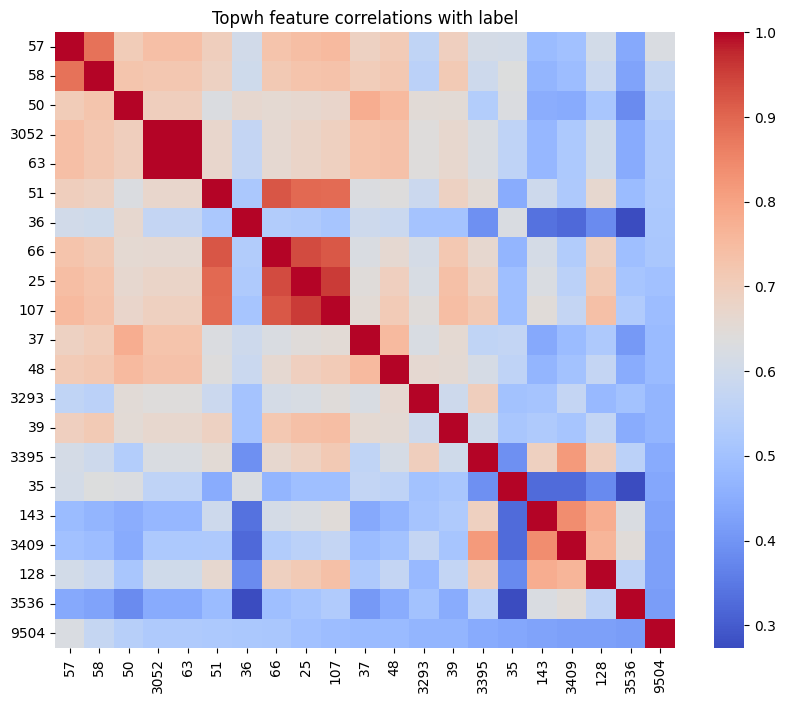

In [ ]:


top_features = mi_scores.sort_values(ascending=False).head(50).index
corr_matrix = df[top_features + [9504]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Top features correlations with label")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_reduced = X[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#model - RandomForestClassifier with hyperparameters tuned for multiclass classification
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
target_names = [label_map[i] for i in sorted(label_map.keys())]

print("Multiclass Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Multiclass Accuracy: 0.8525873031399784

Classification Report:
              precision    recall  f1-score   support

      benign       0.89      0.97      0.93     32547
      adware       0.79      0.70      0.74      9405
    backdoor       0.35      0.21      0.26       290
      banker       0.50      0.11      0.18       162
     dropper       0.41      0.08      0.13       442
fileinjector       0.38      0.50      0.43       133
  NoCategory       0.42      0.10      0.17       471
         PUA       0.53      0.17      0.26       405
  Ransomware       0.86      0.67      0.76      1268
    Riskware       0.87      0.91      0.89     19415
         SMS       0.92      0.66      0.77       626
   Scareware       0.58      0.04      0.08       319
         Spy       0.81      0.79      0.80       692
      Trojan       0.62      0.69      0.66      2719
     Zeroday       0.66      0.39      0.49      2667

    accuracy                           0.85     71561
   macro avg    

In [ ]:
#cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_reduced, y, cv=5)
print(scores.mean())

In [ ]:
# Detailed classification report with target names

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=target_names))

In [ ]:

import shap
from sklearn.ensemble import RandomForestClassifier

rf_shap = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, # Limited depth for faster SHAP calculation
    random_state=42, 
    n_jobs=-1
)
rf_shap.fit(X_train, y_train)

# 2. Initialize the Explainer
# TreeExplainer is optimized specifically for Random Forests
explainer = shap.TreeExplainer(rf_shap)

# 3. Generate SHAP values for a sample
# We use a sample because calculating SHAP for the whole test set is slow
X_sample = X_test.sample(500)
shap_values = explainer.shap_values(X_sample)



Generating Detailed Beeswarm for Class 1...


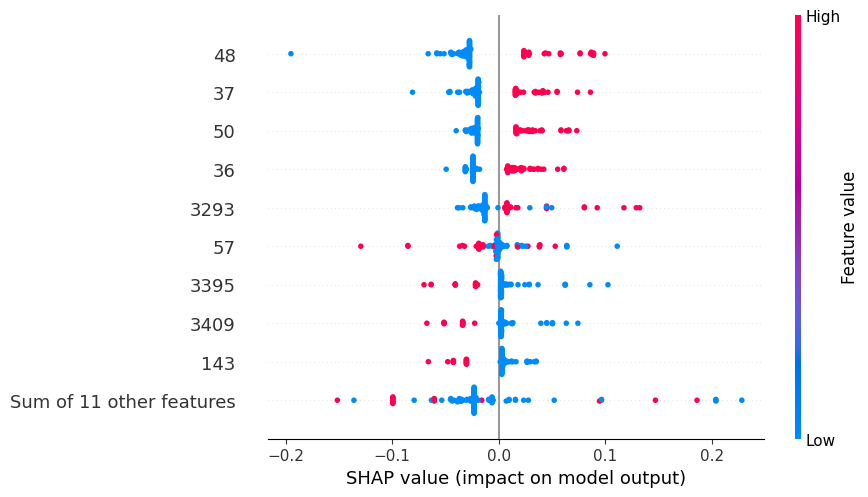

In [17]:
target_class_index = 1 
print(f"Generating Detailed Beeswarm for Class {target_class_index}...")
shap.plots.beeswarm(shap_values[:, :, target_class_index])

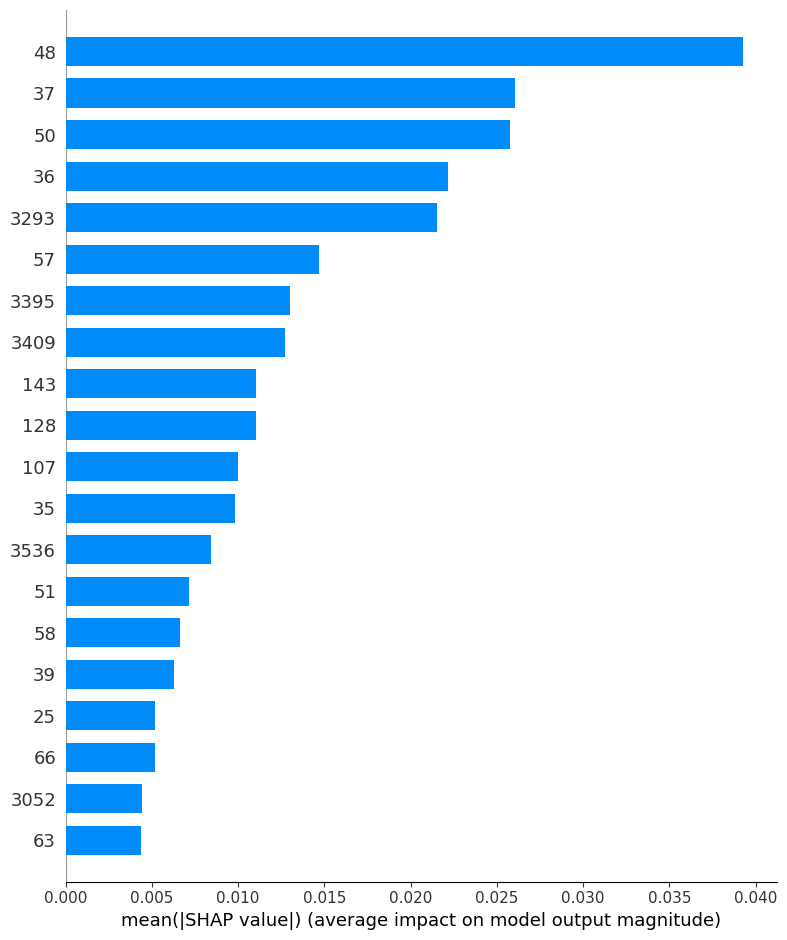

In [18]:
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

Generating explanation for Class: benign (Index 0)


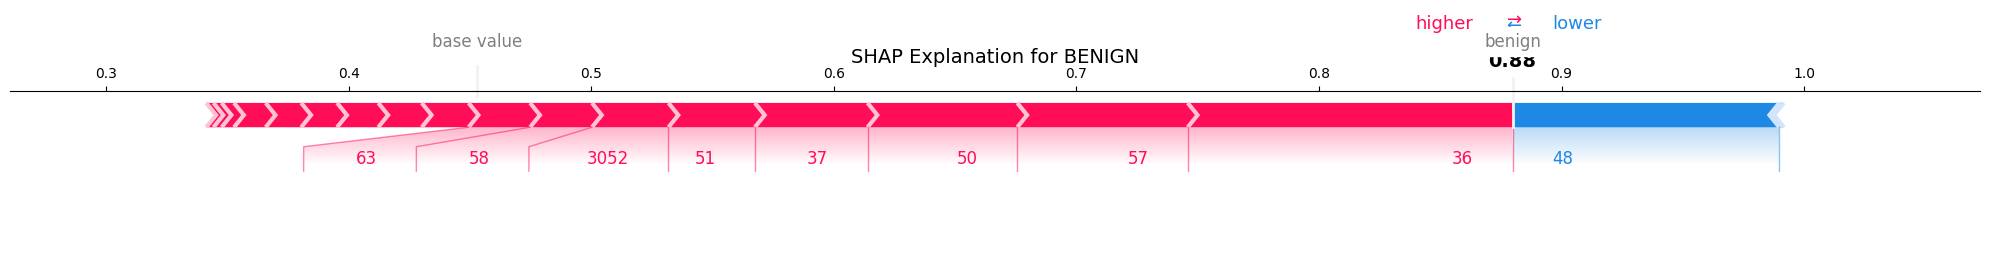

Generating explanation for Class: adware (Index 1)


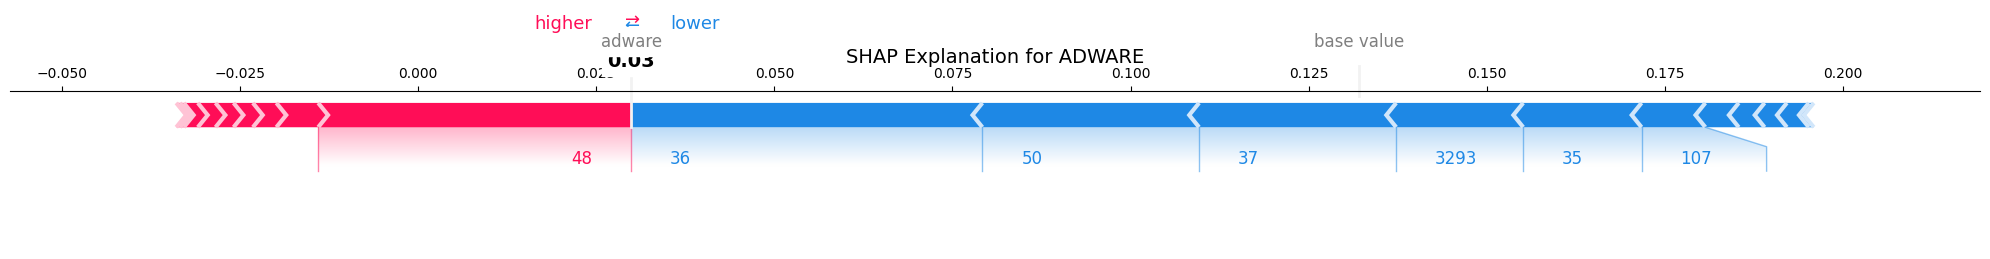

Generating explanation for Class: backdoor (Index 2)


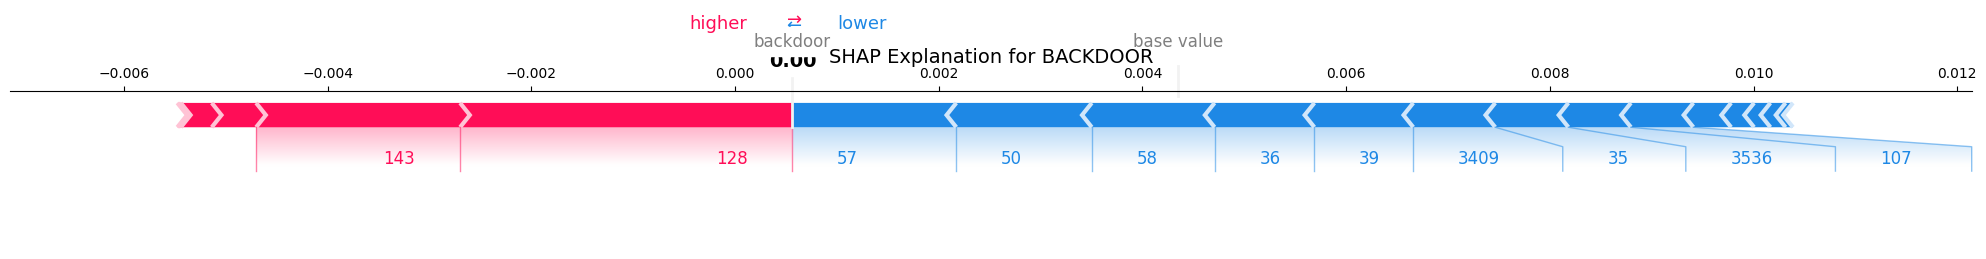

Generating explanation for Class: banker (Index 3)


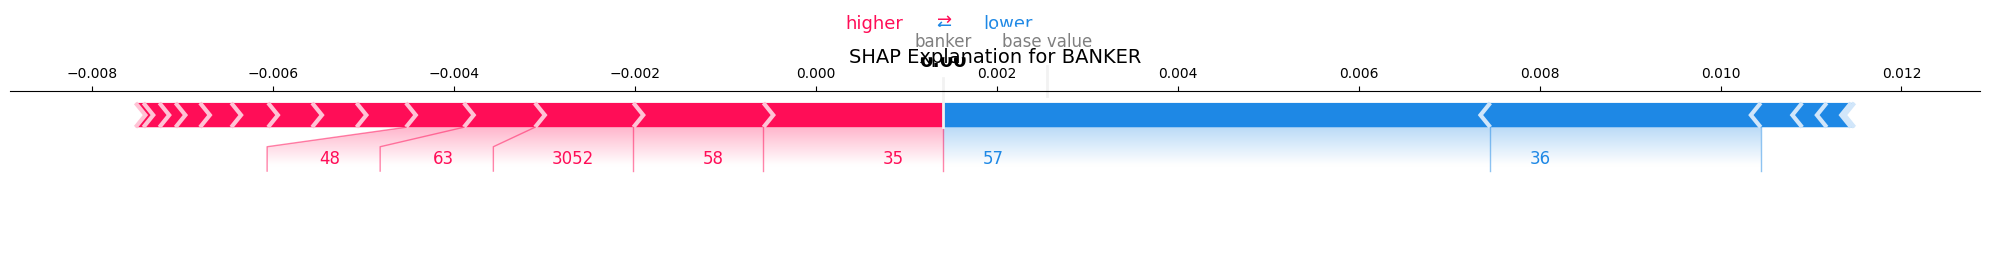

Generating explanation for Class: dropper (Index 4)


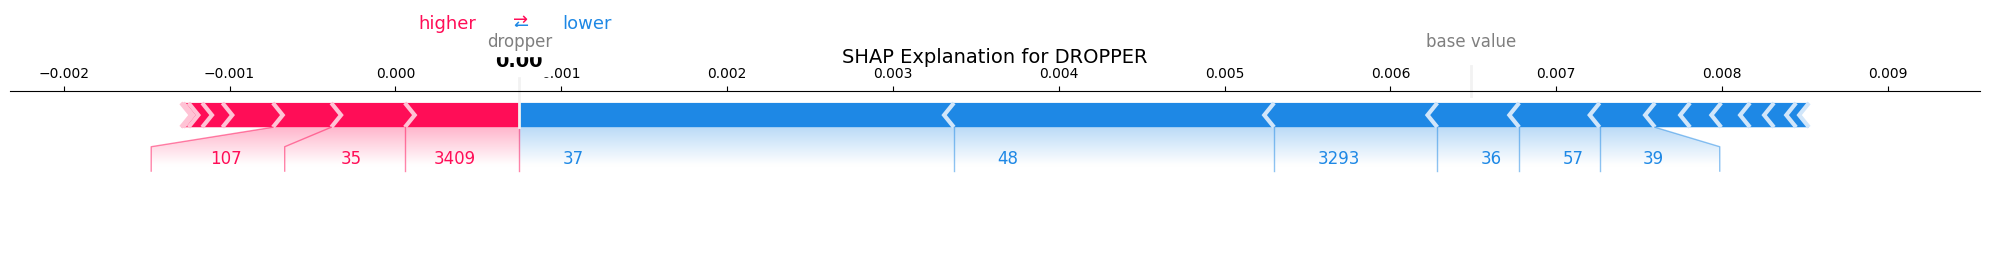

Generating explanation for Class: fileinjector (Index 5)


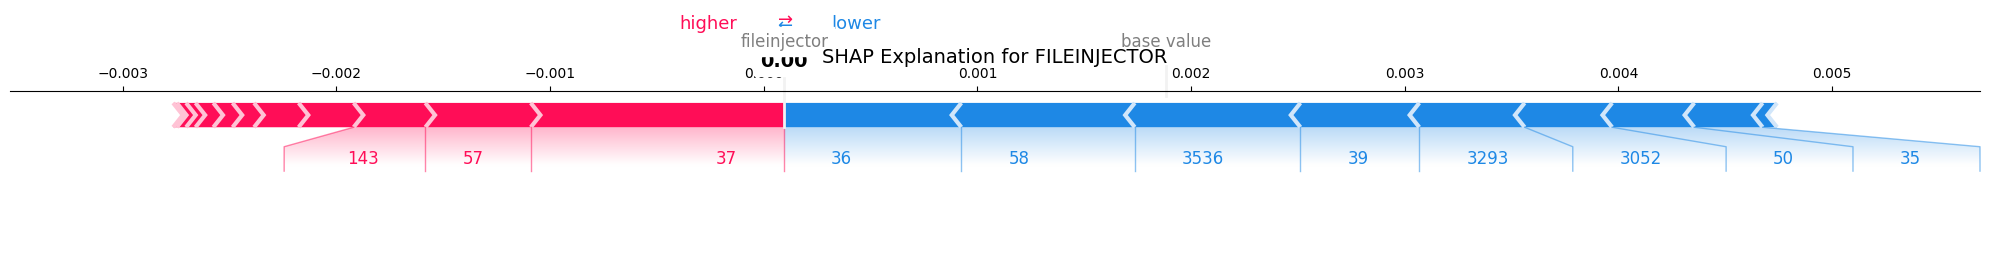

Generating explanation for Class: NoCategory (Index 6)


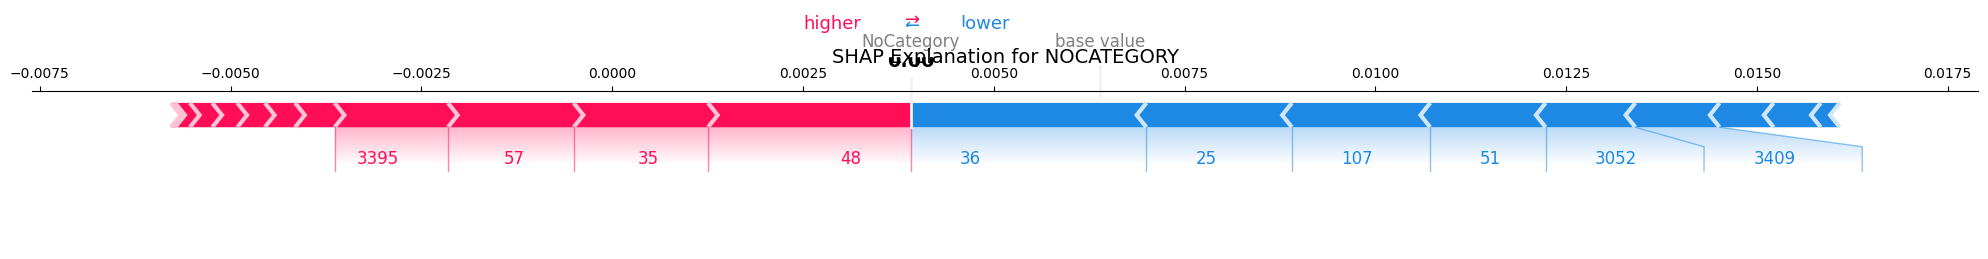

Generating explanation for Class: PUA (Index 7)


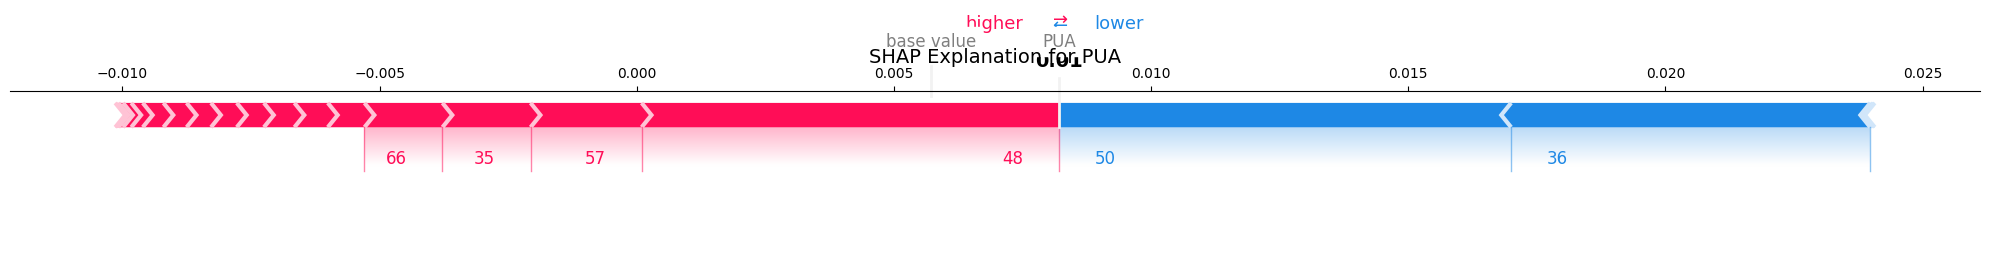

Generating explanation for Class: Ransomware (Index 8)


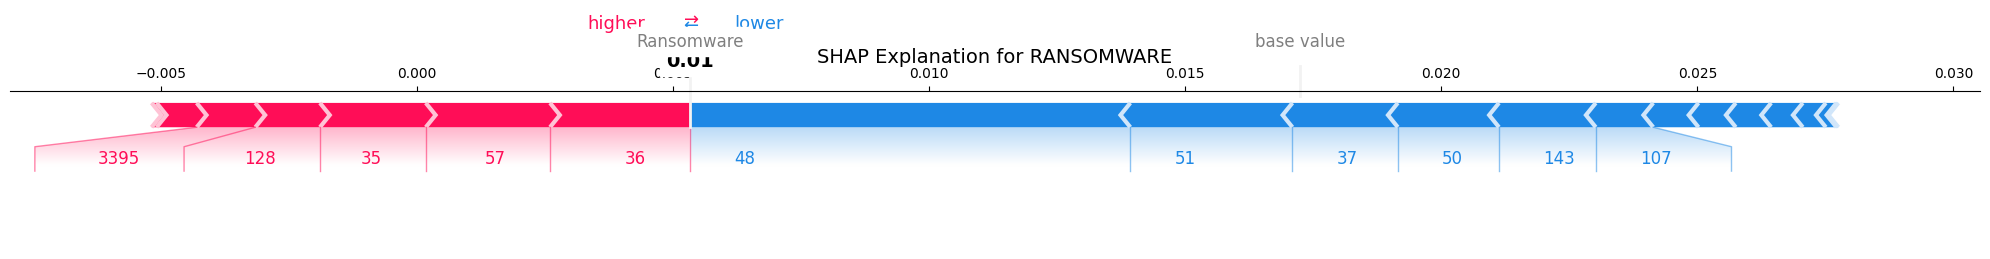

Generating explanation for Class: Riskware (Index 9)


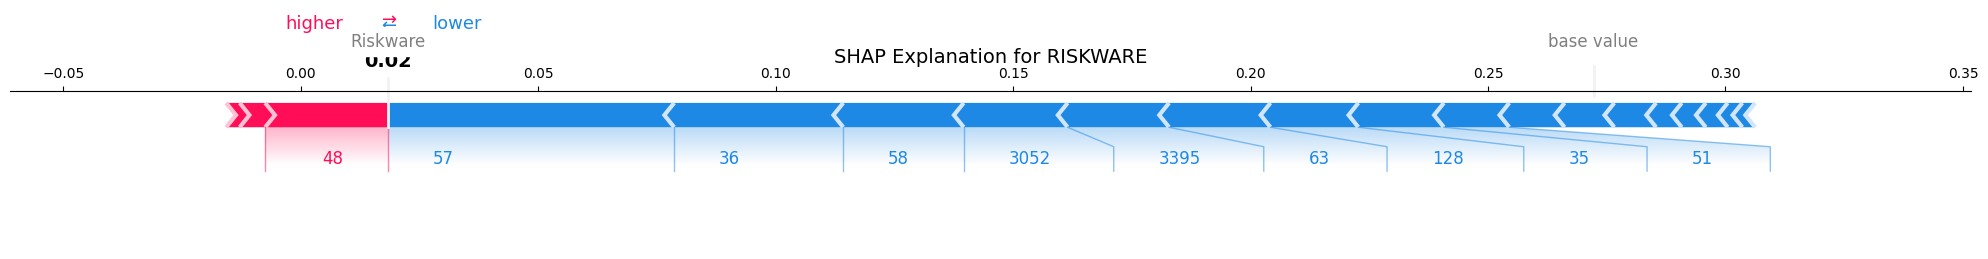

Generating explanation for Class: SMS (Index 10)


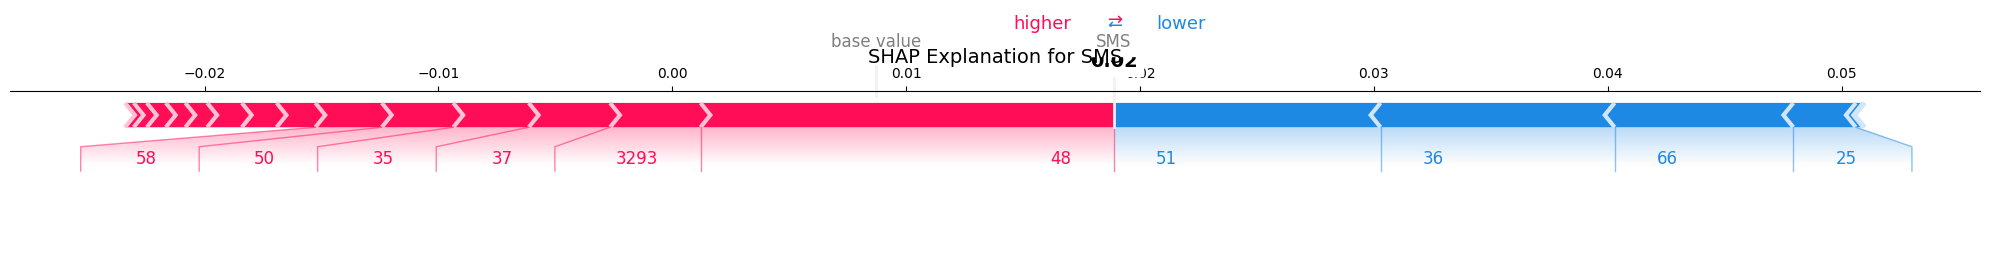

Generating explanation for Class: Scareware (Index 11)


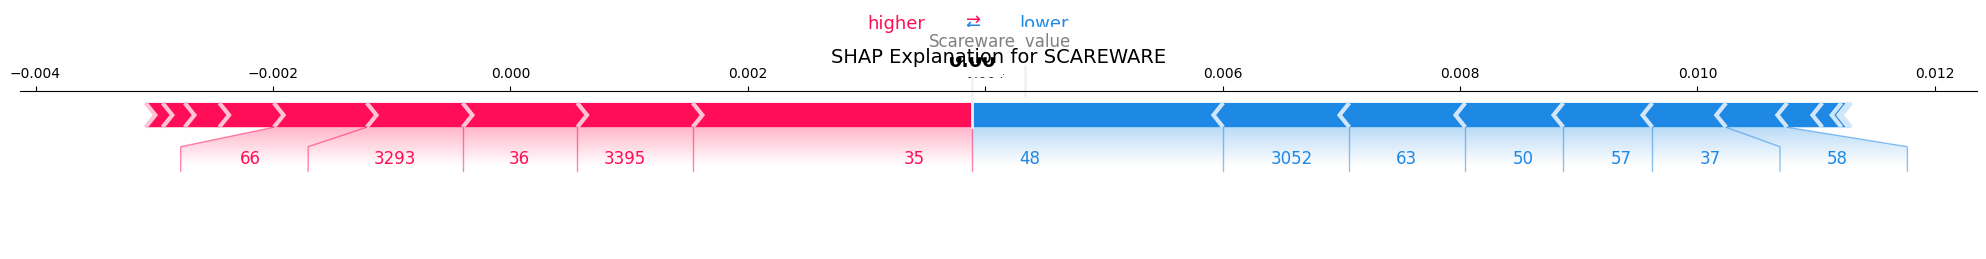

Generating explanation for Class: Spy (Index 12)


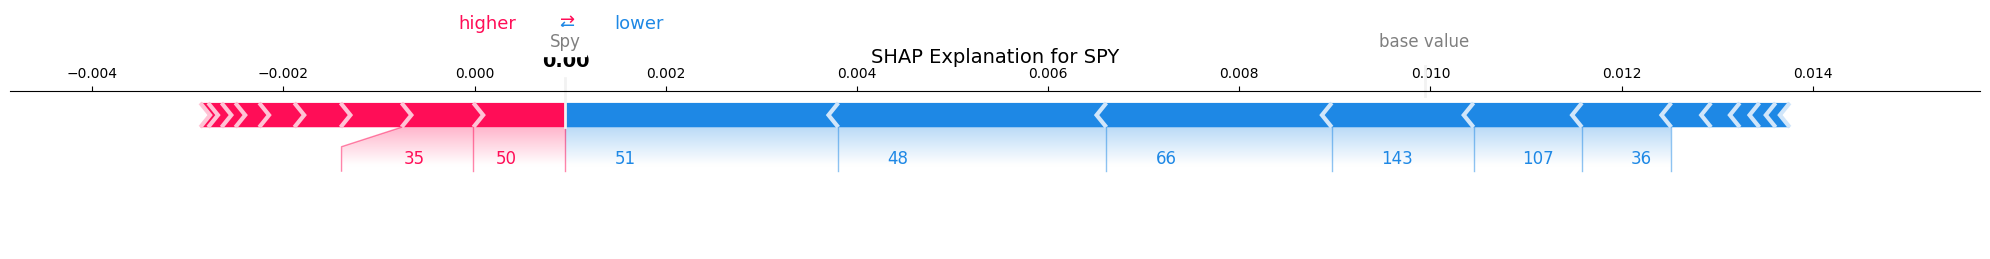

Generating explanation for Class: Trojan (Index 13)


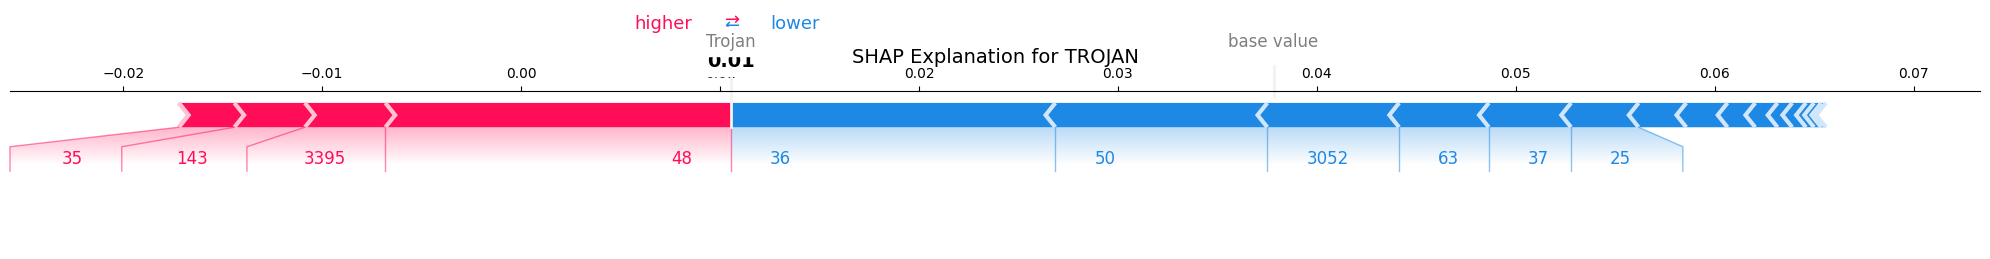

Generating explanation for Class: Zeroday (Index 14)


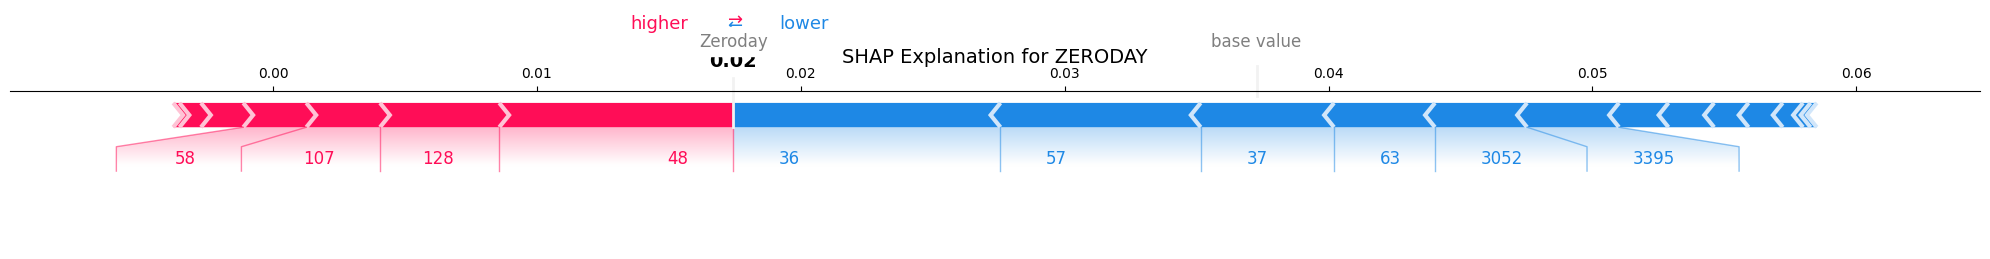

In [25]:
inv_label_map = {v: k for k, v in label_map.items()}



# 2. Select the app and the class you want to explain
i = 0  # Index of the Android app in X_sample


for idx in range(len(inv_label_map)): 
 target_class_index = idx # Example: Explain why it might be 'adware'

# 3. Prepare data for the plot
# Using .astype(float) prevents the UFuncTypeError by ensuring numbers aren't objects
 features_row = X_sample.iloc[i, :]
 feature_names = X_sample.columns.tolist()
 features_display = [str(val) for val in features_row.values]
 class_name = inv_label_map[target_class_index]

# 4. Generate the Force Plot
 print(f"Generating explanation for Class: {class_name} (Index {target_class_index})")

 shap.force_plot(
    float(explainer.expected_value[target_class_index]), 
    shap_values.values[i, :, target_class_index], 
    features_display,
    feature_names=feature_names,
    out_names=class_name, # This labels the final value as the specific malware type
    matplotlib=True,
    show=False
 )

# 5. Clean up the title and layout
 plt.title(f"SHAP Explanation for {class_name.upper()}", fontsize=14, pad=20)
 plt.tight_layout()
 plt.show()


In [35]:
sample = X_test.sample(n=100, random_state=42).reset_index(drop=True)
pred = model.predict(sample)

# 1. Setup the explainer and explanations
explainer = shap.TreeExplainer(model)
# Note: For some RF versions, you might need to use shap_values = explainer.shap_values(sample)
# but the standard explainer call is usually preferred:
shap_explanations = explainer(sample, check_additivity=False)

# Inverse label map to show names instead of numbers
inv_label_map = {v: k for k, v in label_map.items()}

# 2. Iterate through the predictions
for i, app_pred_idx in enumerate(pred):
    # Get the human-readable name of the predicted class
    predicted_class_name = inv_label_map[app_pred_idx]
    
    # DYNAMIC INDEXING: 
    # Get the SHAP values for the specific class that was PREDICTED
    # shap_explanations.values shape is (samples, features, classes)
    current_shap_values = shap_explanations.values[i, :, app_pred_idx]
    feature_names = sample.columns
    
    # Sort features by their impact (top 3)
    top_indices = np.argsort(np.abs(current_shap_values))[-3:][::-1]
    
    reasons = []
    for idx in top_indices:
        val = current_shap_values[idx]
        feature_name = feature_names[idx]
        
        # If SHAP is positive, it increased the probability of this class
        # If SHAP is negative, it decreased the probability
        if val > 0:
            direction = f"increased evidence for {predicted_class_name}"
        else:
            direction = f"decreased evidence for {predicted_class_name}"
            
        reasons.append(f"{feature_name} ({direction} by {abs(val):.4f})")
        
    print(f"App {i}: Predicted as [{predicted_class_name.upper()}]")
    print(f"   Top Reasons: {', '.join(reasons)}\n")

App 0: Predicted as [BENIGN]
   Top Reasons: 3395 (decreased evidence for benign by 0.0187), 128 (increased evidence for benign by 0.0147), 143 (decreased evidence for benign by 0.0129)

App 1: Predicted as [BENIGN]
   Top Reasons: 143 (decreased evidence for benign by 0.0184), 36 (increased evidence for benign by 0.0129), 3293 (increased evidence for benign by 0.0122)

App 2: Predicted as [BENIGN]
   Top Reasons: 35 (increased evidence for benign by 0.0098), 3293 (decreased evidence for benign by 0.0075), 3395 (increased evidence for benign by 0.0064)

App 3: Predicted as [BENIGN]
   Top Reasons: 3395 (decreased evidence for benign by 0.0187), 128 (increased evidence for benign by 0.0147), 143 (decreased evidence for benign by 0.0129)

App 4: Predicted as [BENIGN]
   Top Reasons: 36 (increased evidence for benign by 0.0035), 3395 (increased evidence for benign by 0.0022), 48 (decreased evidence for benign by 0.0021)

App 5: Predicted as [BENIGN]
   Top Reasons: 3395 (decreased evidenc

In [ ]:
from xgboost import XGBClassifier

modelx = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    tree_method="hist",
    n_jobs=-1
)

modelx.fit(X_train, y_train)

# Evaluation
y_pred = modelx.predict(X_test)
target_names = [label_map[i] for i in sorted(label_map.keys())]

print("Multiclass Accuracy:", modelx.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))